# Exploratory Data Analysis - Credit Card Fraud Detection

**Objective:** Understand the dataset structure, distributions, and patterns to inform feature engineering and model selection.

**Dataset:** Credit Card Fraud Detection (Kaggle)
- 284,807 transactions over 2 days
- 492 frauds (0.172% of all transactions)
- Features: Time, V1-V28 (PCA components), Amount, Class

## 1. Setup and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

%matplotlib inline

In [2]:
df = pd.read_csv('../data/raw/creditcard.csv')
print(f"Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")

Dataset loaded: 284,807 rows × 31 columns


## 2. Dataset Overview

In [3]:
df.head(10)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
5,2.0,-0.425966,0.960523,1.141109,-0.168252,0.420987,-0.029728,0.476201,0.260314,-0.568671,...,-0.208254,-0.559825,-0.026398,-0.371427,-0.232794,0.105915,0.253844,0.081080,3.67,0
6,4.0,1.229658,0.141004,0.045371,1.202613,0.191881,0.272708,-0.005159,0.081213,0.464960,...,-0.167716,-0.270710,-0.154104,-0.780055,0.750137,-0.257237,0.034507,0.005168,4.99,0
7,7.0,-0.644269,1.417964,1.074380,-0.492199,0.948934,0.428118,1.120631,-3.807864,0.615375,...,1.943465,-1.015455,0.057504,-0.649709,-0.415267,-0.051634,-1.206921,-1.085339,40.80,0
8,7.0,-0.894286,0.286157,-0.113192,-0.271526,2.669599,3.721818,0.370145,0.851084,-0.392048,...,-0.073425,-0.268092,-0.204233,1.011592,0.373205,-0.384157,0.011747,0.142404,93.20,0
9,9.0,-0.338262,1.119593,1.044367,-0.222187,0.499361,-0.246761,0.651583,0.069539,-0.736727,...,-0.246914,-0.633753,-0.120794,-0.385050,-0.069733,0.094199,0.246219,0.083076,3.68,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [5]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [8]:
print("Missing Values:")
print(df.isnull().sum().sum())
print("\nDuplicate Rows:")
print(df.duplicated().sum())

Missing Values:
0

Duplicate Rows:
1081


## 3. Target Variable Analysis

In [9]:
class_counts = df['Class'].value_counts()
fraud_percentage = (class_counts[1] / len(df)) * 100

print("Class Distribution:")
print(f"Normal Transactions: {class_counts[0]:,} ({100 - fraud_percentage:.3f}%)")
print(f"Fraudulent Transactions: {class_counts[1]:,} ({fraud_percentage:.3f}%)")
print(f"\nImbalance Ratio: {class_counts[0] / class_counts[1]:.2f}:1")

Class Distribution:
Normal Transactions: 284,315 (99.827%)
Fraudulent Transactions: 492 (0.173%)

Imbalance Ratio: 577.88:1


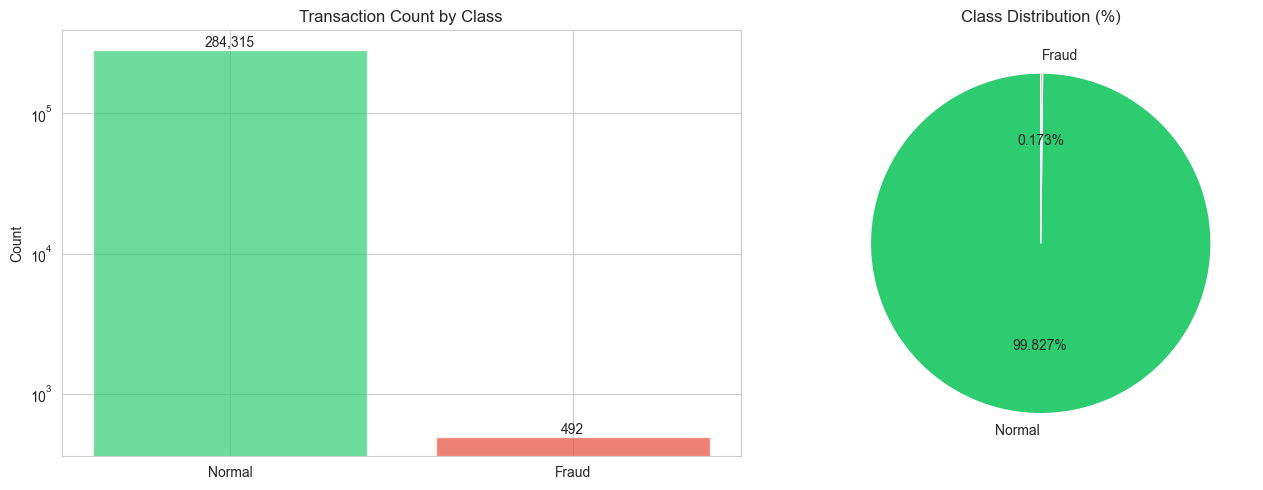

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(['Normal', 'Fraud'], class_counts.values, color=['#2ecc71', '#e74c3c'], alpha=0.7)
axes[0].set_ylabel('Count')
axes[0].set_title('Transaction Count by Class')
axes[0].set_yscale('log')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v, f'{v:,}', ha='center', va='bottom')

colors = ['#2ecc71', '#e74c3c']
axes[1].pie(class_counts.values, labels=['Normal', 'Fraud'], autopct='%1.3f%%', 
            colors=colors, startangle=90)
axes[1].set_title('Class Distribution (%)')

plt.tight_layout()
plt.show()

## 4. Time Analysis

In [11]:
df['Time_Hour'] = df['Time'] / 3600

print(f"Time Range: {df['Time'].min():.0f}s to {df['Time'].max():.0f}s")
print(f"Duration: {df['Time'].max() / 3600:.1f} hours ({df['Time'].max() / 86400:.1f} days)")

Time Range: 0s to 172792s
Duration: 48.0 hours (2.0 days)


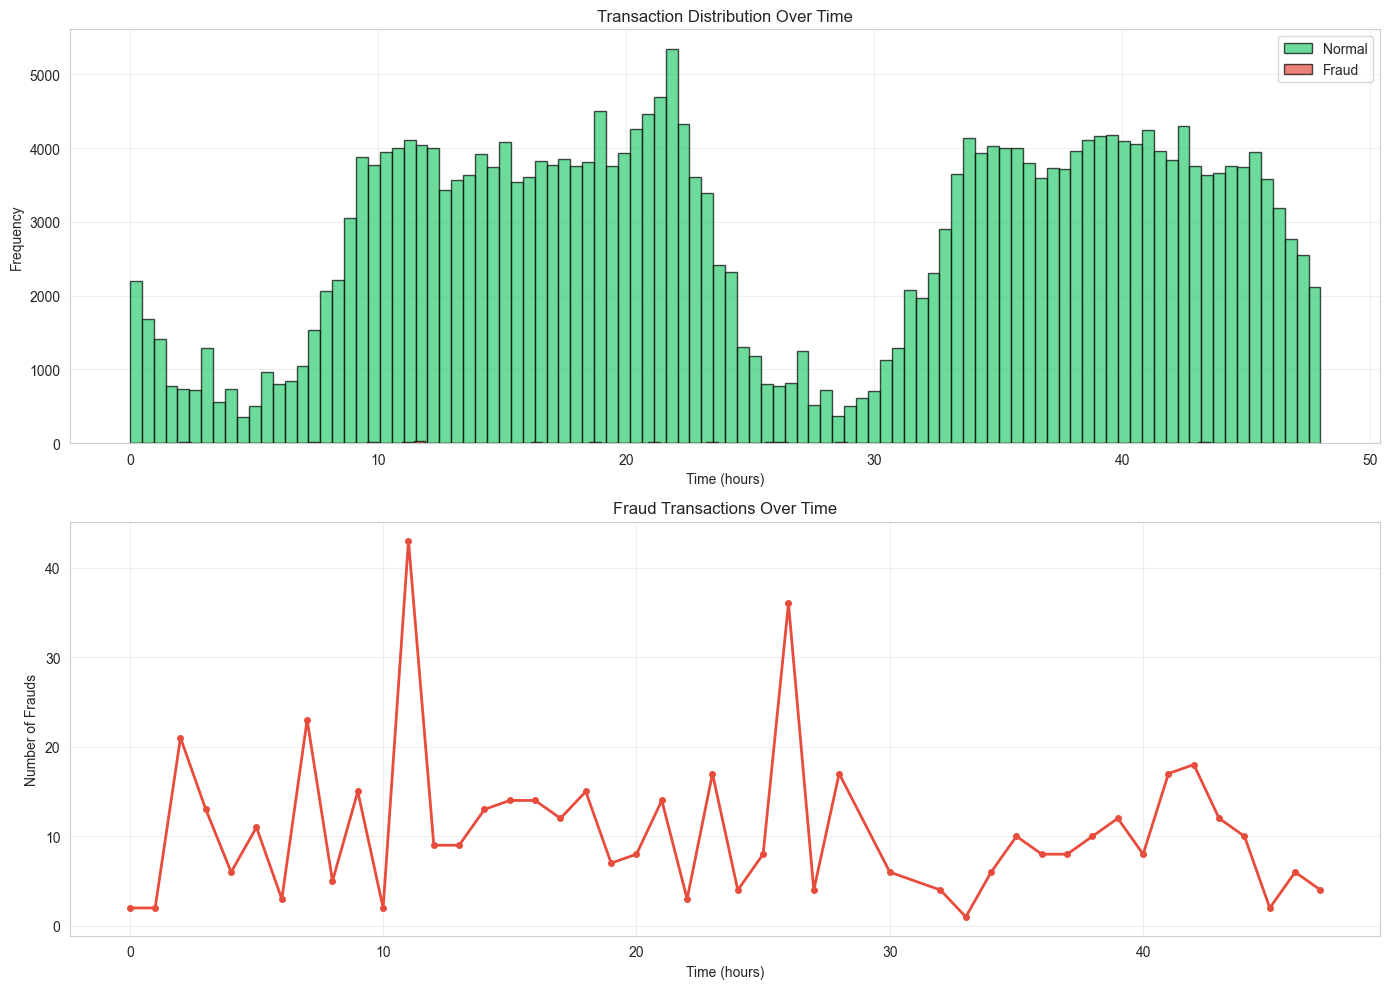

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

axes[0].hist(df[df['Class'] == 0]['Time_Hour'], bins=100, alpha=0.7, 
             label='Normal', color='#2ecc71', edgecolor='black')
axes[0].hist(df[df['Class'] == 1]['Time_Hour'], bins=100, alpha=0.7, 
             label='Fraud', color='#e74c3c', edgecolor='black')
axes[0].set_xlabel('Time (hours)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Transaction Distribution Over Time')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

fraud_by_hour = df[df['Class'] == 1].groupby(df['Time_Hour'].astype(int)).size()
axes[1].plot(fraud_by_hour.index, fraud_by_hour.values, marker='o', 
             linewidth=2, markersize=4, color='#e74c3c')
axes[1].set_xlabel('Time (hours)')
axes[1].set_ylabel('Number of Frauds')
axes[1].set_title('Fraud Transactions Over Time')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Amount Analysis

In [13]:
print("Amount Statistics:")
print(f"\nOverall:")
print(df['Amount'].describe())
print(f"\nNormal Transactions:")
print(df[df['Class'] == 0]['Amount'].describe())
print(f"\nFraudulent Transactions:")
print(df[df['Class'] == 1]['Amount'].describe())

Amount Statistics:

Overall:
count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64

Normal Transactions:
count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64

Fraudulent Transactions:
count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64


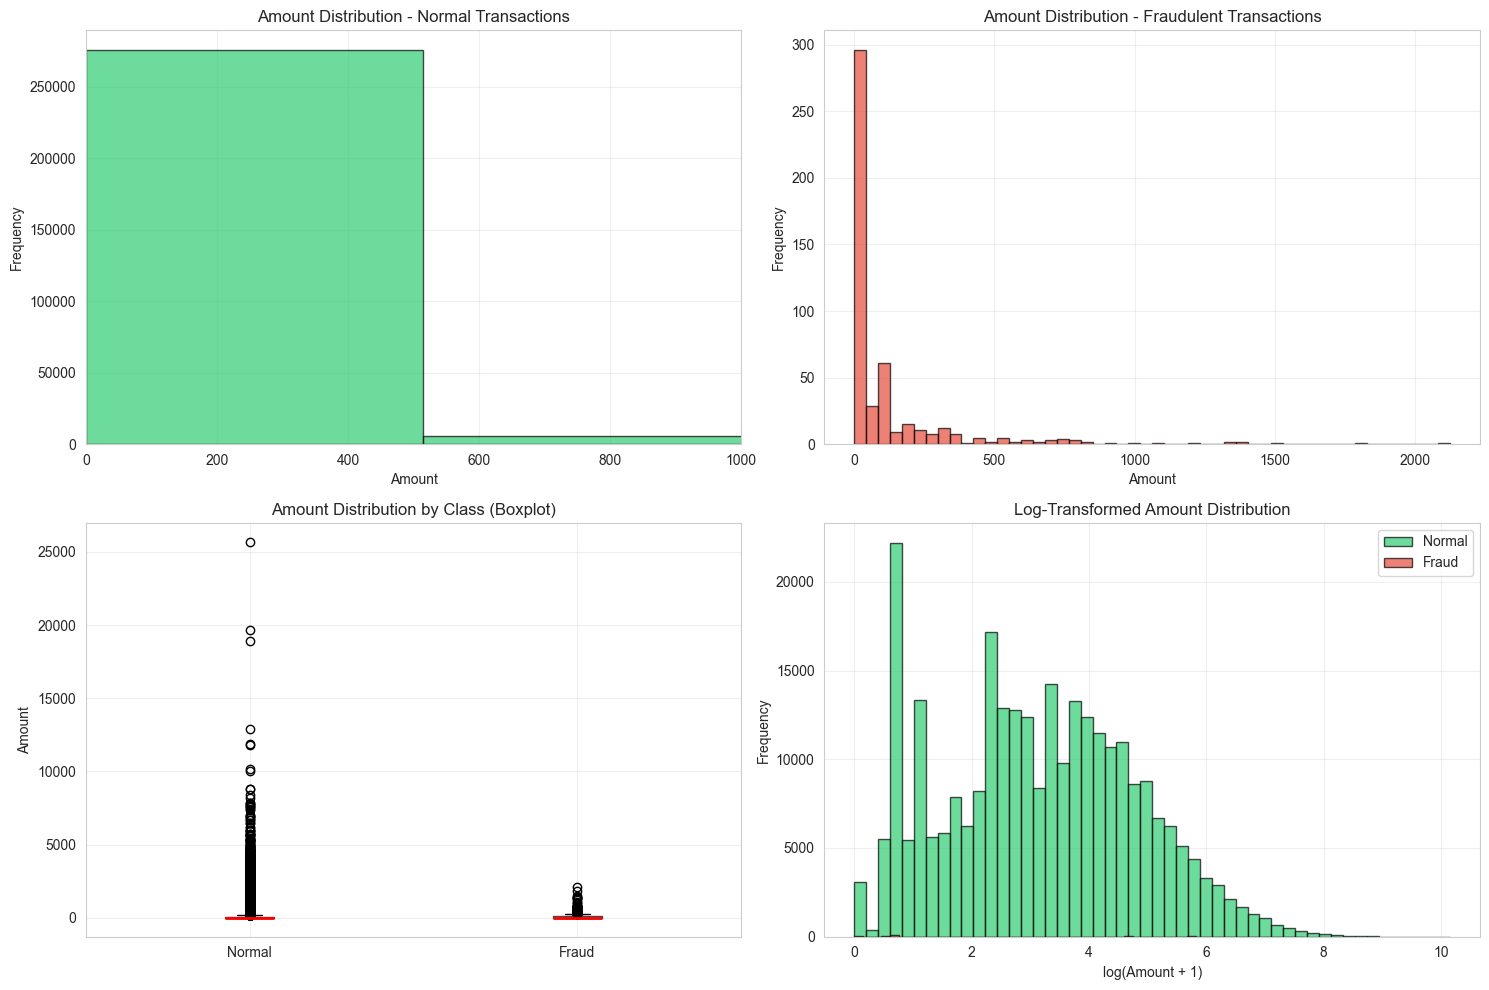

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

axes[0, 0].hist(df[df['Class'] == 0]['Amount'], bins=50, alpha=0.7, 
                label='Normal', color='#2ecc71', edgecolor='black')
axes[0, 0].set_xlabel('Amount')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Amount Distribution - Normal Transactions')
axes[0, 0].set_xlim(0, 1000)
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].hist(df[df['Class'] == 1]['Amount'], bins=50, alpha=0.7, 
                label='Fraud', color='#e74c3c', edgecolor='black')
axes[0, 1].set_xlabel('Amount')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Amount Distribution - Fraudulent Transactions')
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].boxplot([df[df['Class'] == 0]['Amount'], df[df['Class'] == 1]['Amount']], 
                    labels=['Normal', 'Fraud'], patch_artist=True,
                    boxprops=dict(facecolor='lightblue', alpha=0.7),
                    medianprops=dict(color='red', linewidth=2))
axes[1, 0].set_ylabel('Amount')
axes[1, 0].set_title('Amount Distribution by Class (Boxplot)')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].hist(np.log1p(df[df['Class'] == 0]['Amount']), bins=50, alpha=0.7, 
                label='Normal', color='#2ecc71', edgecolor='black')
axes[1, 1].hist(np.log1p(df[df['Class'] == 1]['Amount']), bins=50, alpha=0.7, 
                label='Fraud', color='#e74c3c', edgecolor='black')
axes[1, 1].set_xlabel('log(Amount + 1)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Log-Transformed Amount Distribution')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. PCA Features Analysis (V1-V28)

In [15]:
v_features = [f'V{i}' for i in range(1, 29)]

print("PCA Features Statistics:")
print(df[v_features].describe())

PCA Features Statistics:
                 V1            V2            V3            V4            V5  \
count  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean   1.168375e-15  3.416908e-16 -1.379537e-15  2.074095e-15  9.604066e-16   
std    1.958696e+00  1.651309e+00  1.516255e+00  1.415869e+00  1.380247e+00   
min   -5.640751e+01 -7.271573e+01 -4.832559e+01 -5.683171e+00 -1.137433e+02   
25%   -9.203734e-01 -5.985499e-01 -8.903648e-01 -8.486401e-01 -6.915971e-01   
50%    1.810880e-02  6.548556e-02  1.798463e-01 -1.984653e-02 -5.433583e-02   
75%    1.315642e+00  8.037239e-01  1.027196e+00  7.433413e-01  6.119264e-01   
max    2.454930e+00  2.205773e+01  9.382558e+00  1.687534e+01  3.480167e+01   

                 V6            V7            V8            V9           V10  \
count  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean   1.487313e-15 -5.556467e-16  1.213481e-16 -2.406331e-15  2.239053e-15   
std    1.332271e+00  1.237

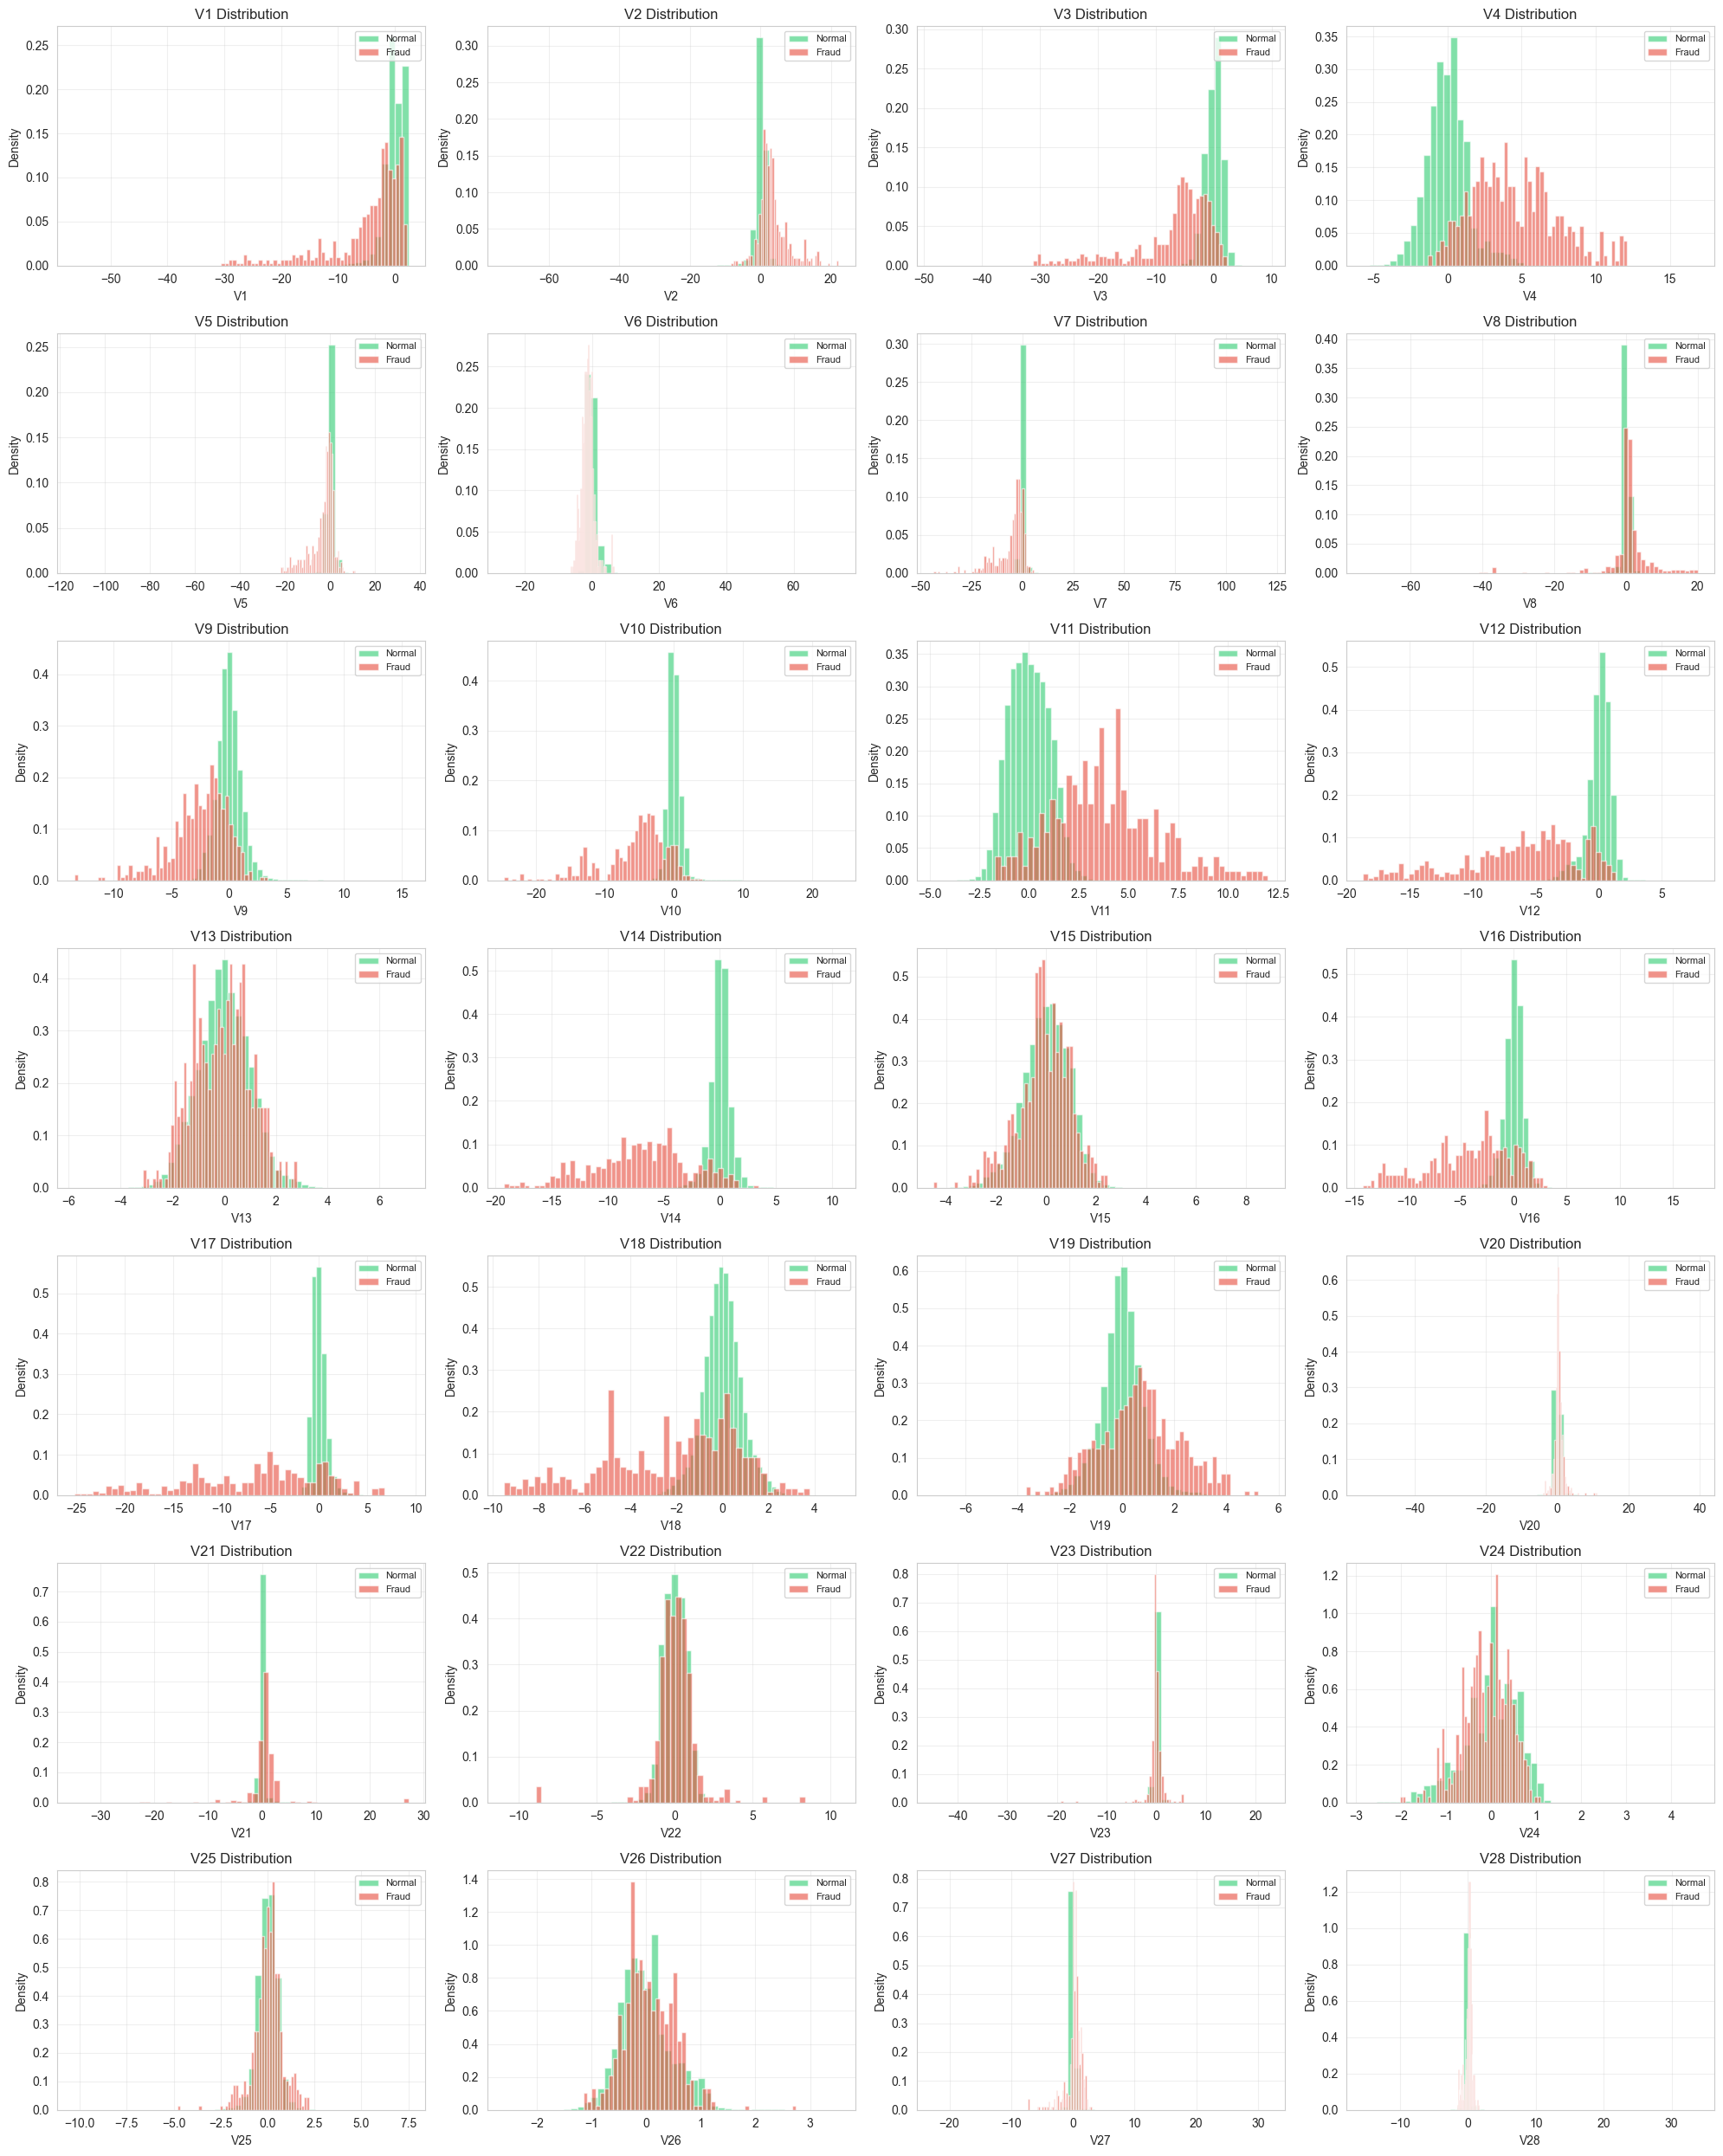

In [16]:
fig, axes = plt.subplots(7, 4, figsize=(20, 25))
axes = axes.ravel()

for idx, feature in enumerate(v_features):
    axes[idx].hist(df[df['Class'] == 0][feature], bins=50, alpha=0.6, 
                   label='Normal', color='#2ecc71', density=True)
    axes[idx].hist(df[df['Class'] == 1][feature], bins=50, alpha=0.6, 
                   label='Fraud', color='#e74c3c', density=True)
    axes[idx].set_title(f'{feature} Distribution')
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel('Density')
    axes[idx].legend(loc='upper right', fontsize=8)
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Correlation Analysis

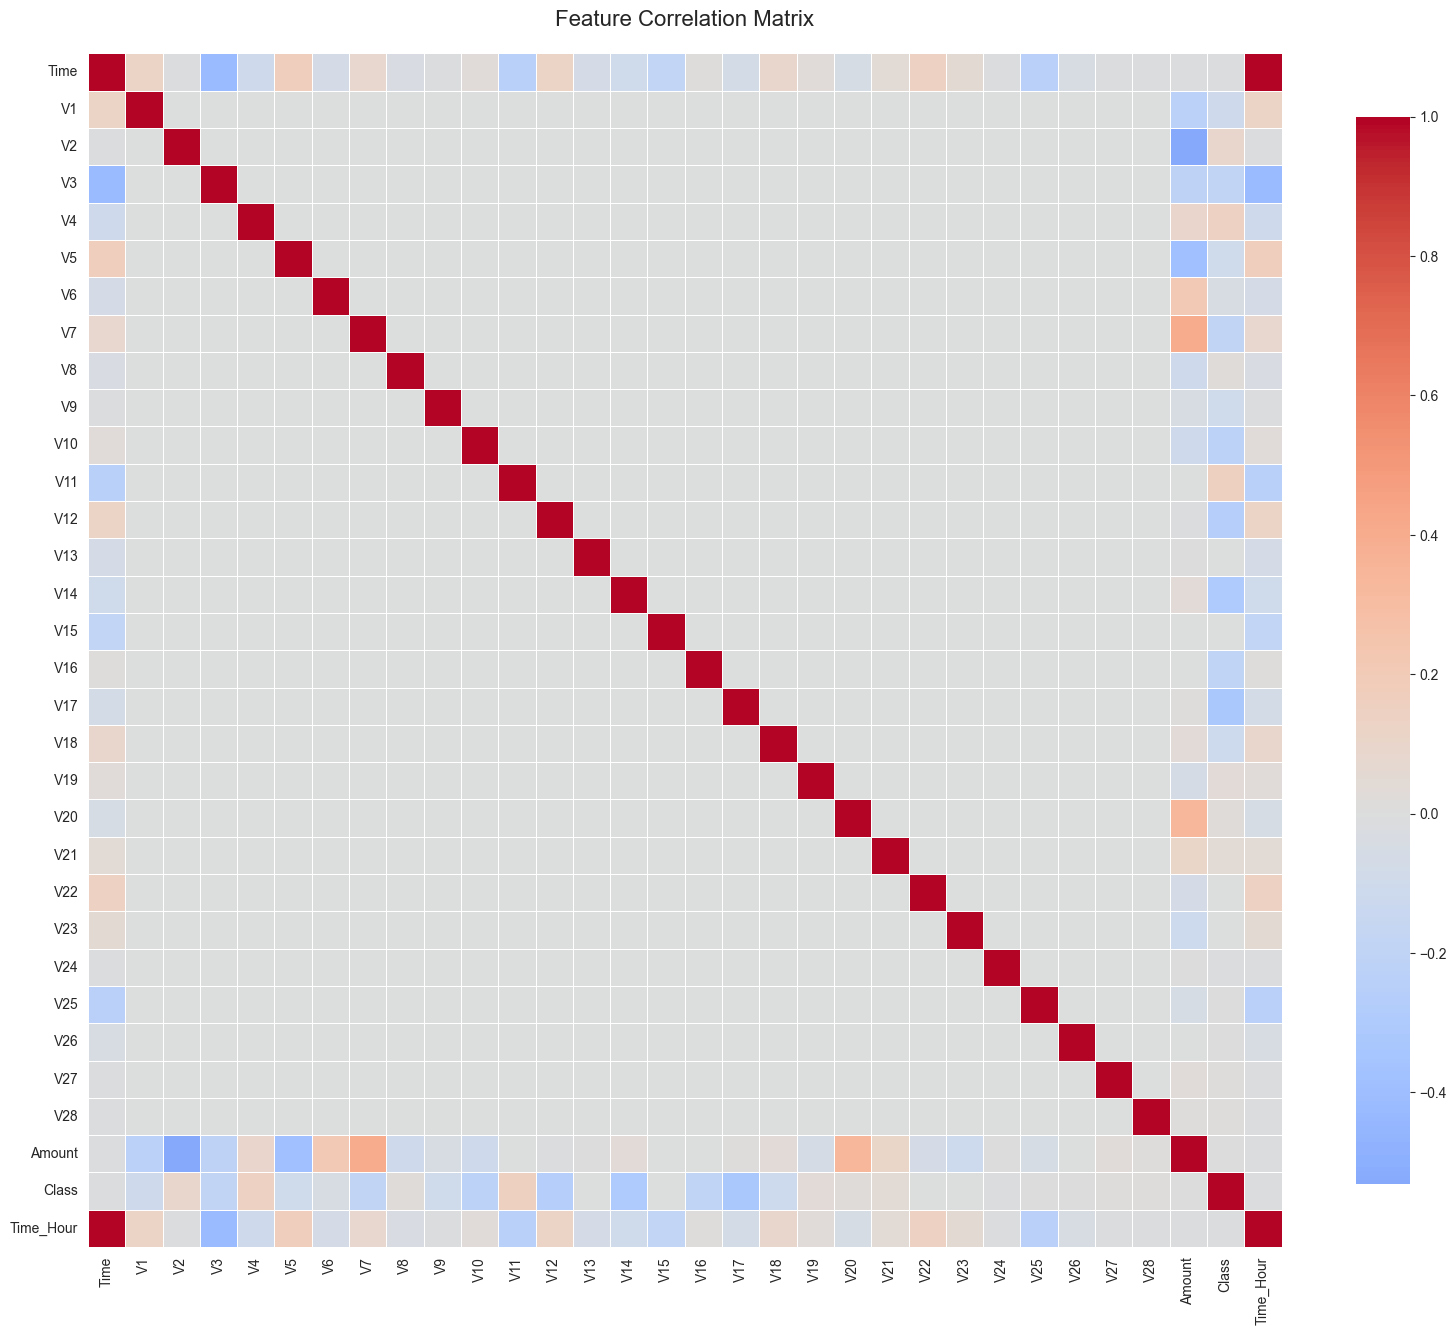

In [17]:
correlation_matrix = df.corr()

plt.figure(figsize=(16, 14))
sns.heatmap(correlation_matrix, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

In [18]:
class_correlation = df.corrwith(df['Class']).drop('Class').sort_values(ascending=False)

print("Top 10 Features Most Correlated with Fraud:")
print(class_correlation.head(10))
print("\nTop 10 Features Most Negatively Correlated with Fraud:")
print(class_correlation.tail(10))

Top 10 Features Most Correlated with Fraud:
V11       0.154876
V4        0.133447
V2        0.091289
V21       0.040413
V19       0.034783
V20       0.020090
V8        0.019875
V27       0.017580
V28       0.009536
Amount    0.005632
dtype: float64

Top 10 Features Most Negatively Correlated with Fraud:
V9    -0.097733
V1    -0.101347
V18   -0.111485
V7    -0.187257
V3    -0.192961
V16   -0.196539
V10   -0.216883
V12   -0.260593
V14   -0.302544
V17   -0.326481
dtype: float64


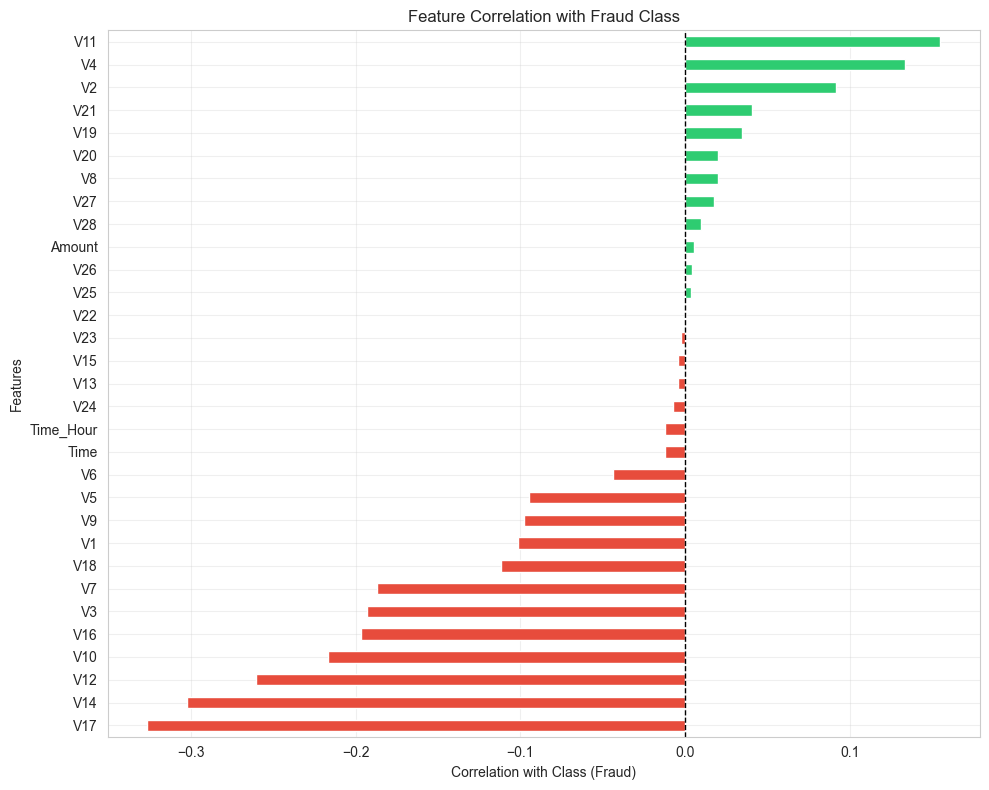

In [19]:
plt.figure(figsize=(10, 8))
class_correlation.sort_values().plot(kind='barh', color=['#e74c3c' if x < 0 else '#2ecc71' 
                                                           for x in class_correlation.sort_values()])
plt.xlabel('Correlation with Class (Fraud)')
plt.ylabel('Features')
plt.title('Feature Correlation with Fraud Class')
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Key Insights Summary

In [20]:
print("=" * 80)
print("KEY FINDINGS FROM EDA")
print("=" * 80)

print("\n1. CLASS IMBALANCE:")
print(f"   - Severe imbalance: {class_counts[0] / class_counts[1]:.2f}:1 ratio")
print(f"   - Only {fraud_percentage:.3f}% of transactions are fraudulent")
print("   - Action: SMOTE, class weights, or ensemble methods needed")

print("\n2. FEATURE ENGINEERING OPPORTUNITIES:")
print("   - Time: No missing values, could create time-based features (hour, day)")
print("   - Amount: Highly skewed, log transformation recommended")
print("   - V features: Already PCA-transformed, mostly normalized")

print("\n3. MOST IMPORTANT FEATURES (based on correlation):")
positive_corr = class_correlation[class_correlation > 0].sort_values(ascending=False).head(3)
negative_corr = class_correlation[class_correlation < 0].sort_values().head(3)
print("   Positive correlation:")
for feat, corr in positive_corr.items():
    print(f"      {feat}: {corr:.4f}")
print("   Negative correlation:")
for feat, corr in negative_corr.items():
    print(f"      {feat}: {corr:.4f}")

print("\n4. DATA QUALITY:")
print(f"   - No missing values")
print(f"   - No duplicate rows")
print(f"   - Clean dataset ready for modeling")

print("\n5. NEXT STEPS:")
print("   - Normalize/scale Amount and Time features")
print("   - Train-test split with stratification")
print("   - Apply SMOTE or other balancing techniques")
print("   - Test multiple algorithms (LR, RF, XGBoost, Isolation Forest)")
print("   - Focus on Precision, Recall, F1, and ROC-AUC metrics")
print("=" * 80)

KEY FINDINGS FROM EDA

1. CLASS IMBALANCE:
   - Severe imbalance: 577.88:1 ratio
   - Only 0.173% of transactions are fraudulent
   - Action: SMOTE, class weights, or ensemble methods needed

2. FEATURE ENGINEERING OPPORTUNITIES:
   - Time: No missing values, could create time-based features (hour, day)
   - Amount: Highly skewed, log transformation recommended
   - V features: Already PCA-transformed, mostly normalized

3. MOST IMPORTANT FEATURES (based on correlation):
   Positive correlation:
      V11: 0.1549
      V4: 0.1334
      V2: 0.0913
   Negative correlation:
      V17: -0.3265
      V14: -0.3025
      V12: -0.2606

4. DATA QUALITY:
   - No missing values
   - No duplicate rows
   - Clean dataset ready for modeling

5. NEXT STEPS:
   - Normalize/scale Amount and Time features
   - Train-test split with stratification
   - Apply SMOTE or other balancing techniques
   - Test multiple algorithms (LR, RF, XGBoost, Isolation Forest)
   - Focus on Precision, Recall, F1, and ROC-A